# Automated AI Review Rating Prediction System

#  1. Load the Dataset


In [3]:
# Import required library
import pandas as pd

In [36]:
# Load Dataset
df = pd.read_csv("/content/flipkart_product.csv", encoding='latin1', engine='python')

# Display first 5 rows
print(df.head())

                                         ProductName     Price Rate  \
0  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
1  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    5   
2  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   
3  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    1   
4  Candes 12 L Room/Personal Air Cooler?ÿ?ÿ(White...  ??3,999    3   

            Review                                            Summary  
0           Super!  Great cooler.. excellent air flow and for this...  
1          Awesome             Best budget 2 fit cooler. Nice cooling  
2             Fair  The quality is good but the power of air is de...  
3  Useless product                 Very bad product it's a only a fan  
4             Fair                                      Ok ok product  


In [37]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Display basic information
print("\nDataset Information:")
print(df.info())

Dataset Shape: (189874, 5)

Columns:
Index(['ProductName', 'Price', 'Rate', 'Review', 'Summary'], dtype='object')

Data Types:
ProductName    object
Price          object
Rate           object
Review         object
Summary        object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 189874 entries, 0 to 189873
Data columns (total 5 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   ProductName  189874 non-null  object
 1   Price        189873 non-null  object
 2   Rate         189873 non-null  object
 3   Review       189870 non-null  object
 4   Summary      189860 non-null  object
dtypes: object(5)
memory usage: 7.2+ MB
None


# 2. Preprocessing

## 2.1 Handle Missing Data


In [38]:
# Missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
ProductName     0
Price           1
Rate            1
Review          4
Summary        14
dtype: int64


In [39]:
df = df.dropna(subset=['Review'])

In [40]:
df = df.dropna(subset=['Rate'])

In [41]:
df = df.dropna(subset=['Price'])

In [42]:
df['Summary'] = df['Summary'].fillna('')

In [43]:
print("Missing Values After Cleaning:")
print(df.isnull().sum())

Missing Values After Cleaning:
ProductName    0
Price          0
Rate           0
Review         0
Summary        0
dtype: int64


In [44]:
print("Dataset Shape After Missing Value Handling:")
print(df.shape)

Dataset Shape After Missing Value Handling:
(189870, 5)


In [45]:
df.reset_index(drop=True, inplace=True)

## 2.2 Remove Duplicates and Conflicts


In [46]:
print("Shape Before:", df.shape)

Shape Before: (189870, 5)


In [47]:
duplicate_count = df.duplicated().sum()

print("Duplicate Records:", duplicate_count)

Duplicate Records: 24861


In [48]:
df = df.drop_duplicates()

print("Shape After:", df.shape)

Shape After: (165009, 5)


In [49]:
# Number of unique ratings for each review text
conflict_counts = df.groupby('Review')['Rate'].nunique()

# Reviews having more than one rating
conflicting_reviews = conflict_counts[conflict_counts > 1]

print("Number of conflicting review texts:",
      len(conflicting_reviews))

# Total rows affected
conflict_rows = df[df['Review'].isin(conflicting_reviews.index)]

print("Rows involved in conflicts:",
      len(conflict_rows))

Number of conflicting review texts: 80
Rows involved in conflicts: 162626


In [50]:
# Keep conflicting reviews
print("Conflicting reviews analyzed and retained.")

Conflicting reviews analyzed and retained.


In [19]:
# Conflicting reviews were analyzed and retained
print("Conflicting reviews retained due to high data loss risk.")

Conflicting reviews retained due to high data loss risk.


## 2.3 Drop Unnecessary Columns/Rows


In [51]:
# Drop irrelevant columns
df = df.drop(columns=['ProductName', 'Summary', 'Price'])

# Check remaining columns
print(df.columns)

# Check shape
print(df.shape)

Index(['Rate', 'Review'], dtype='object')
(165009, 2)


## 2.4 Clean the Review Text and Text Normalization


In [52]:
import re
import string

In [53]:
def clean_text(text):

    # Convert to string and lowercase
    text = str(text).lower()

    # Remove punctuation
    text = text.translate(
        str.maketrans('', '', string.punctuation)
    )

    # Remove special characters and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [54]:
df['Clean_Review'] = df['Review'].apply(clean_text)

In [55]:
print(df[['Review', 'Clean_Review']].head(10))

               Review        Clean_Review
0              Super!               super
1             Awesome             awesome
2                Fair                fair
3     Useless product     useless product
4                Fair                fair
5             Awesome             awesome
6  Highly recommended  highly recommended
7                Nice                nice
8      Unsatisfactory      unsatisfactory
9     Worth the money     worth the money


In [56]:
empty_reviews = (df['Clean_Review'].str.strip() == '').sum()

print("Empty Reviews:", empty_reviews)

Empty Reviews: 4


In [57]:
df = df[df['Clean_Review'].str.strip() != '']

In [58]:
import nltk

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [59]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def normalize_text(text):

    text = str(text)

    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # Remove emojis and non-ascii characters
    text = text.encode('ascii', 'ignore').decode('ascii')

    # Tokenize
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Lemmatization
    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

In [60]:
df['Processed_Review'] = df['Clean_Review'].apply(normalize_text)

In [61]:
print(df[['Clean_Review', 'Processed_Review']].head())

      Clean_Review Processed_Review
0            super            super
1          awesome          awesome
2             fair             fair
3  useless product  useless product
4             fair             fair


## 2.5 Remove Very Short Reviews


In [62]:
df['word_count'] = df['Processed_Review'].apply(
    lambda x: len(x.split())
)

In [63]:
print(df['word_count'].describe())

count    165005.000000
mean          1.573601
std           0.653307
min           0.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          13.000000
Name: word_count, dtype: float64


In [64]:
# Remove only empty reviews

df = df[df['Processed_Review'].str.strip() != '']

# Recalculate word count
df['word_count'] = df['Processed_Review'].apply(
    lambda x: len(x.split())
)

In [66]:
print("Dataset Shape:", df.shape)

print(df['word_count'].describe())

Dataset Shape: (165004, 5)
count    165004.000000
mean          1.573610
std           0.653298
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          13.000000
Name: word_count, dtype: float64


The dataset does not contain excessively long reviews.

The longest review after preprocessing contains only 13 words, which is very small compared to typical review datasets where long reviews may contain hundreds of words

## 2.6 Basic Feature Engineering


In [67]:
df['review_length'] = df['Processed_Review'].apply(len)

In [68]:
df['char_count'] = df['Processed_Review'].str.len()

In [69]:
print(
    (df['review_length'] == df['char_count']).all()
)

True


In [70]:
print(df.columns)
print(df.shape)

Index(['Rate', 'Review', 'Clean_Review', 'Processed_Review', 'word_count',
       'review_length', 'char_count'],
      dtype='object')
(165004, 7)


## 2.7 Check Final Class Distribution


In [71]:
print("Class Distribution:\n")
print(df['Rate'].value_counts().sort_index())

Class Distribution:

Rate
1                                                              18782
2                                                               6014
3                                                              13945
4                                                              33207
5                                                              93052
Bajaj DX 2 L/W Dry Iron                                            1
Nova Plus Amaze NI 10 1100 W Dry Iron?ÿ?ÿ(Grey & Turquoise)        1
Pigeon Favourite Electric Kettle?ÿ?ÿ(1.5 L, Silver, Black)         1
s                                                                  1
Name: count, dtype: int64


In [73]:
print(df['Rate'].unique())

['5' '3' '1' '4' '2'
 'Pigeon Favourite Electric Kettle?ÿ?ÿ(1.5 L, Silver, Black)'
 'Bajaj DX 2 L/W Dry Iron'
 'Nova Plus Amaze NI 10 1100 W Dry Iron?ÿ?ÿ(Grey & Turquoise)' 's']


In [75]:
valid_ratings = ['1', '2', '3', '4', '5']

df = df[df['Rate'].astype(str).isin(valid_ratings)]

In [76]:
df['Rate'] = df['Rate'].astype(int)

In [77]:
print(df['Rate'].value_counts().sort_index())

Rate
1    18782
2     6014
3    13945
4    33207
5    93052
Name: count, dtype: int64


In [79]:
print(df.shape)

(165000, 7)


In [78]:
print("\nPercentage Distribution:\n")

print(
    round(
        df['Rate'].value_counts(normalize=True)
        .sort_index() * 100,
        2
    )
)


Percentage Distribution:

Rate
1    11.38
2     3.64
3     8.45
4    20.13
5    56.40
Name: proportion, dtype: float64


In [80]:
class_distribution = pd.DataFrame({
    'Count': df['Rate'].value_counts().sort_index(),
    'Percentage (%)': round(
        df['Rate'].value_counts(normalize=True)
        .sort_index() * 100, 2
    )
})

print(class_distribution)

      Count  Percentage (%)
Rate                       
1     18782           11.38
2      6014            3.64
3     13945            8.45
4     33207           20.13
5     93052           56.40


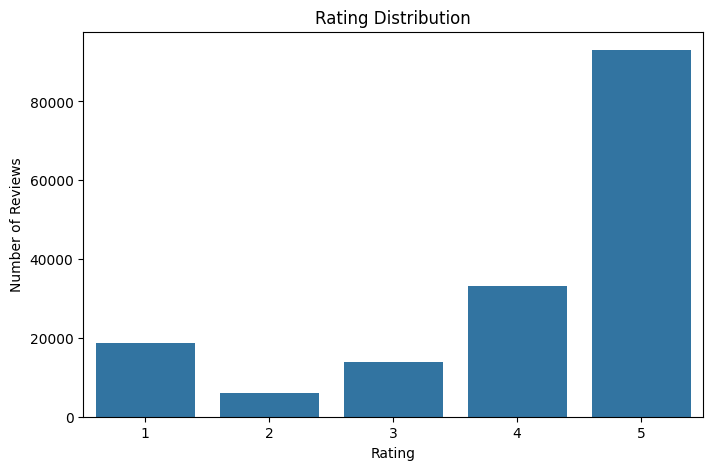

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='Rate',
    data=df,
    order=sorted(df['Rate'].unique())
)

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

## 2.8 Save the Cleaned Dataset


In [82]:
df.to_csv(
    "flipkart_reviews_cleaned.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [83]:
cleaned_df = pd.read_csv("/content/flipkart_reviews_cleaned.csv")

print(cleaned_df.shape)
print(cleaned_df.head())

(165000, 7)
   Rate           Review     Clean_Review Processed_Review  word_count  \
0     5           Super!            super            super           1   
1     5          Awesome          awesome          awesome           1   
2     3             Fair             fair             fair           1   
3     1  Useless product  useless product  useless product           2   
4     3             Fair             fair             fair           1   

   review_length  char_count  
0              5           5  
1              7           7  
2              4           4  
3             15          15  
4              4           4  


# 3.  Data Visualization

## 3.1 Rating Distribution





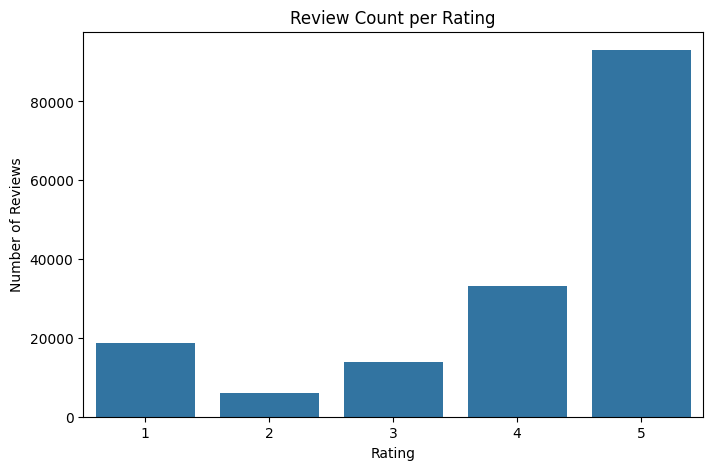

In [84]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.countplot(
    x='Rate',
    data=df,
    order=sorted(df['Rate'].unique())
)

plt.title('Review Count per Rating')
plt.xlabel('Rating')
plt.ylabel('Number of Reviews')

plt.show()

Identifies class imbalance.
Shows which ratings dominate the dataset.
Helps justify balancing techniques later.

## 3.2 Review Length Distribution


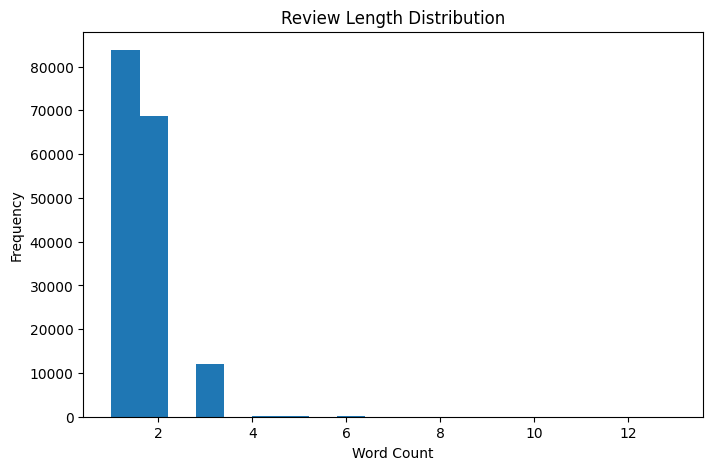

In [85]:
plt.figure(figsize=(8,5))

plt.hist(
    df['word_count'],
    bins=20
)

plt.title('Review Length Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')

plt.show()

Shows how long reviews typically are.
Detects unusually short or long reviews.

## 3.3 Boxplot of Word count per Rating


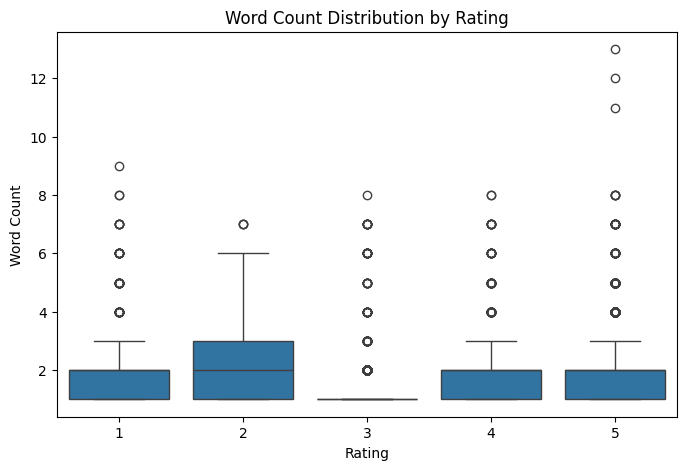

In [86]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Rate',
    y='word_count',
    data=df
)

plt.title('Word Count Distribution by Rating')
plt.xlabel('Rating')
plt.ylabel('Word Count')

plt.show()

Compare median review lengths.
Detect outliers.
Determine whether negative reviews are longer than positive reviews.

## 3.4 Violin Plot


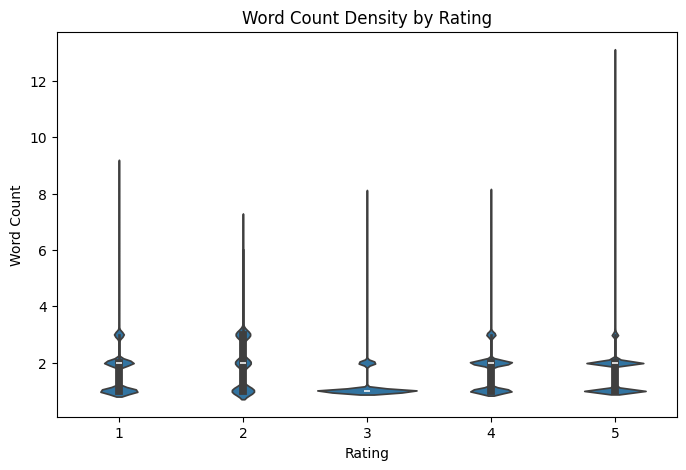

In [87]:
plt.figure(figsize=(8,5))

sns.violinplot(
    x='Rate',
    y='word_count',
    data=df
)

plt.title('Word Count Density by Rating')
plt.xlabel('Rating')
plt.ylabel('Word Count')

plt.show()

Displays review-length density.
Reveals concentration of short reviews.
More informative than a boxplot alone.

## 3.5 Word Frequency Analysis

### Most Common Words Overall

In [88]:
from collections import Counter

all_words = " ".join(
    df['Processed_Review']
).split()

word_freq = Counter(all_words)

common_words = word_freq.most_common(20)

common_words_df = pd.DataFrame(
    common_words,
    columns=['Word','Frequency']
)

print(common_words_df)

           Word  Frequency
0       product      25980
1          good      15222
2           nan      15150
3       awesome       9577
4      purchase       9314
5      terrific       9309
6          nice       8158
7         worth       7790
8     wonderful       7763
9   recommended       5732
10        money       5361
11        great       4865
12    brilliant       4795
13         best       4794
14          buy       4788
15        every       4771
16        penny       4770
17      perfect       4770
18         must       4745
19       classy       4736


### Most Common Words by Rating

In [89]:
from collections import Counter

for rating in sorted(df['Rate'].unique()):

    words = " ".join(
        df[df['Rate']==rating]['Processed_Review']
    ).split()

    common = Counter(words).most_common(10)

    print(f"\nTop Words for Rating {rating}\n")

    for word, freq in common:
        print(word, ":", freq)


Top Words for Rating 1

nan : 2452
product : 2320
waste : 2315
money : 2315
absolute : 1231
rubbish : 1230
disappointed : 1197
utterly : 1191
poor : 1189
worthless : 1174

Top Words for Rating 2

better : 1639
quality : 921
bad : 920
good : 874
product : 868
expected : 856
disappointed : 848
slightly : 845
moderate : 845
nan : 804

Top Words for Rating 3

product : 2068
nice : 2053
good : 2042
decent : 2025
fair : 2020
okay : 2004
job : 1954
nan : 1721
great : 9
buy : 7

Top Words for Rating 4

good : 12060
product : 6215
nice : 6020
quality : 3152
choice : 3041
valueformoney : 3032
really : 3022
wonderful : 3007
delightful : 3007
worth : 2982

Top Words for Rating 5

product : 14509
awesome : 9549
purchase : 9296
terrific : 9290
nan : 7361
great : 4840
worth : 4802
brilliant : 4787
every : 4766
penny : 4764


### Visualize Top Words for Each Rating

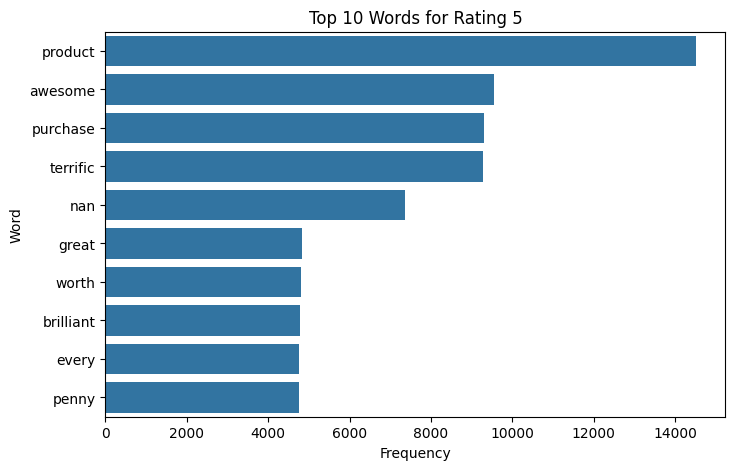

In [90]:
rating = 5

words = " ".join(
    df[df['Rate']==rating]['Processed_Review']
).split()

common_words = Counter(words).most_common(10)

words_df = pd.DataFrame(
    common_words,
    columns=['Word','Frequency']
)

plt.figure(figsize=(8,5))

sns.barplot(
    x='Frequency',
    y='Word',
    data=words_df
)

plt.title(f'Top 10 Words for Rating {rating}')

plt.show()

## 3.6 Display Sample Reviews per Rating

In [91]:
for rating in sorted(df['Rate'].unique()):

    print("\n" + "="*60)
    print(f"Sample Reviews for Rating {rating}")
    print("="*60)

    samples = df[df['Rate']==rating][
        'Review'
    ].sample(
        n=min(5,
        len(df[df['Rate']==rating])),
        random_state=42
    )

    for i, review in enumerate(samples,1):
        print(f"\nReview {i}:")
        print(review)


Sample Reviews for Rating 1

Review 1:
Absolute rubbish!

Review 2:
Terrible product

Review 3:
Worthless

Review 4:
Waste of money!

Review 5:
Useless product

Sample Reviews for Rating 2

Review 1:
Bad quality

Review 2:
Value-for-money

Review 3:
Bad quality

Review 4:
Moderate

Review 5:
Slightly disappointed

Sample Reviews for Rating 3

Review 1:
Nan

Review 2:
Just okay

Review 3:
Good

Review 4:
Just okay

Review 5:
Good

Sample Reviews for Rating 4

Review 1:
Nice product

Review 2:
Good quality product

Review 3:
Worth the money

Review 4:
Nan

Review 5:
Worth the money

Sample Reviews for Rating 5

Review 1:
Brilliant

Review 2:
Classy product

Review 3:
Nan

Review 4:
Awesome

Review 5:
Must buy!


# 4. Creating a Balanced Dataset


In [92]:
import pandas as pd

balanced_data = []

for rating in sorted(df['Rate'].unique()):

    class_data = df[df['Rate'] == rating]

    balanced_class = class_data.sample(
        n=20000,
        replace=True,      # Oversample minority classes
        random_state=42
    )

    balanced_data.append(balanced_class)

balanced_df = pd.concat(
    balanced_data,
    ignore_index=True
)

# Shuffle the dataset
balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [93]:
print(balanced_df['Rate'].value_counts().sort_index())

Rate
1    20000
2    20000
3    20000
4    20000
5    20000
Name: count, dtype: int64


In [94]:
print(balanced_df.shape)

(100000, 7)


In [95]:
balanced_df.to_csv(
    "flipkart_reviews_balanced.csv",
    index=False
)

print("Balanced dataset saved successfully!")

Balanced dataset saved successfully!


# 5. Train-Test Split


In [96]:
X = balanced_df['Processed_Review']
y = balanced_df['Rate']

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [98]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (80000,)
X_test : (20000,)
y_train: (80000,)
y_test : (20000,)


In [99]:
print(y_train.value_counts().sort_index())

Rate
1    16000
2    16000
3    16000
4    16000
5    16000
Name: count, dtype: int64


In [100]:
print(y_test.value_counts().sort_index())

Rate
1    4000
2    4000
3    4000
4    4000
5    4000
Name: count, dtype: int64


## TF-IDF Vectorization

In [101]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [102]:
tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

In [103]:
X_test_tfidf = tfidf.transform(X_test)

In [105]:
print("Train Matrix:", X_train_tfidf.shape)
print("Test Matrix :", X_test_tfidf.shape)

Train Matrix: (80000, 555)
Test Matrix : (20000, 555)


# Model Training using ML models

In [106]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

## 1. Multinomial Naive Bayes

In [107]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))

Naive Bayes Accuracy: 0.8222


In [108]:
print(classification_report(y_test, y_pred_nb))

              precision    recall  f1-score   support

           1       0.99      0.86      0.92      4000
           2       0.99      0.71      0.82      4000
           3       0.62      0.86      0.72      4000
           4       0.71      0.82      0.76      4000
           5       0.99      0.87      0.92      4000

    accuracy                           0.82     20000
   macro avg       0.86      0.82      0.83     20000
weighted avg       0.86      0.82      0.83     20000



## 2. Logistic Regression

In [109]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_tfidf, y_train)

y_pred_lr = lr_model.predict(X_test_tfidf)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.8539


In [110]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

           1       0.70      0.99      0.82      4000
           2       0.79      0.85      0.82      4000
           3       0.99      0.74      0.84      4000
           4       0.93      0.82      0.88      4000
           5       0.99      0.87      0.92      4000

    accuracy                           0.85     20000
   macro avg       0.88      0.85      0.86     20000
weighted avg       0.88      0.85      0.86     20000



## 3. Random Forest

In [111]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)

y_pred_rf = rf_model.predict(X_test_tfidf)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

Random Forest Accuracy: 0.8548


In [112]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           1       0.70      0.99      0.82      4000
           2       0.79      0.85      0.82      4000
           3       0.99      0.74      0.84      4000
           4       0.93      0.83      0.88      4000
           5       0.99      0.87      0.92      4000

    accuracy                           0.85     20000
   macro avg       0.88      0.85      0.86     20000
weighted avg       0.88      0.85      0.86     20000



In [113]:
results = {
    'Naive Bayes':
        accuracy_score(y_test, y_pred_nb),

    'Logistic Regression':
        accuracy_score(y_test, y_pred_lr),

    'Random Forest':
        accuracy_score(y_test, y_pred_rf)
}

for model, acc in results.items():
    print(f"{model}: {acc:.4f}")

Naive Bayes: 0.8222
Logistic Regression: 0.8539
Random Forest: 0.8548


In [114]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(comparison_df)

                 Model  Accuracy
2        Random Forest    0.8548
1  Logistic Regression    0.8539
0          Naive Bayes    0.8222


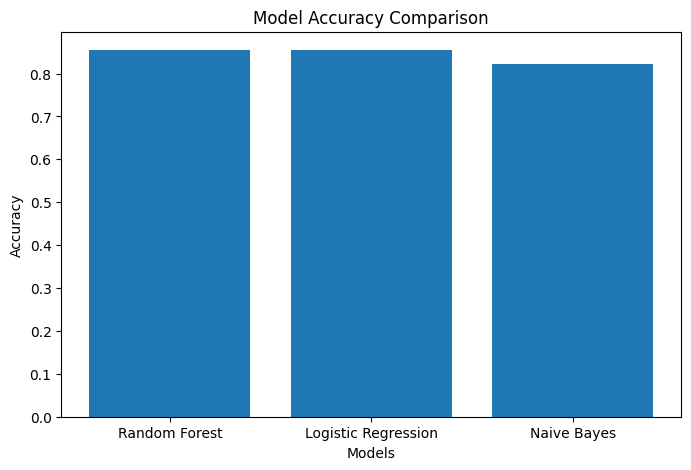

In [115]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

# IMBALANCED DATASET

In [122]:
import pandas as pd

target_counts = {
    1: 10000,
    2: 15000,
    3: 25000,
    4: 30000,
    5: 20000
}

imbalanced_parts = []

for rating, count in target_counts.items():

    class_data = df[df['Rate'] == rating]

    sampled = class_data.sample(
        n=count,
        replace=(len(class_data) < count),
        random_state=42
    )

    imbalanced_parts.append(sampled)

imbalanced_df = pd.concat(
    imbalanced_parts,
    ignore_index=True
)

imbalanced_df = imbalanced_df.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)

In [123]:
print(imbalanced_df['Rate'].value_counts().sort_index())

Rate
1    10000
2    15000
3    25000
4    30000
5    20000
Name: count, dtype: int64


In [124]:
print(
    imbalanced_df['Rate']
    .value_counts(normalize=True)
    .sort_index() * 100
)

Rate
1    10.0
2    15.0
3    25.0
4    30.0
5    20.0
Name: proportion, dtype: float64


## Train-test split

In [125]:
X = imbalanced_df['Processed_Review']
y = imbalanced_df['Rate']

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print("Training Samples:", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples: 80000
Testing Samples : 20000


In [127]:
print(y_train.value_counts().sort_index())

Rate
1     8000
2    12000
3    20000
4    24000
5    16000
Name: count, dtype: int64


In [128]:
print(y_test.value_counts().sort_index())

Rate
1    2000
2    3000
3    5000
4    6000
5    4000
Name: count, dtype: int64


## TF-IDF vectorization

In [129]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000
)

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform(X_test)

print(X_train_tfidf.shape)
print(X_test_tfidf.shape)

(80000, 633)
(20000, 633)


### 1. Multinomial naive bayes

In [130]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

y_pred_nb = nb_model.predict(X_test_tfidf)

print("Naive Bayes Accuracy:",
      accuracy_score(y_test, y_pred_nb))

print(classification_report(
    y_test,
    y_pred_nb
))

Naive Bayes Accuracy: 0.84415
              precision    recall  f1-score   support

           1       0.98      0.80      0.88      2000
           2       0.99      0.71      0.83      3000
           3       0.74      0.85      0.79      5000
           4       0.80      0.91      0.85      6000
           5       0.96      0.86      0.91      4000

    accuracy                           0.84     20000
   macro avg       0.89      0.83      0.85     20000
weighted avg       0.86      0.84      0.85     20000



### 2. Logistic Regression

In [131]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_lr = lr_model.predict(
    X_test_tfidf
)

print("Logistic Regression Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print(classification_report(
    y_test,
    y_pred_lr
))

Logistic Regression Accuracy: 0.85815
              precision    recall  f1-score   support

           1       0.98      0.86      0.91      2000
           2       0.99      0.71      0.83      3000
           3       0.67      0.99      0.80      5000
           4       0.95      0.82      0.88      6000
           5       0.99      0.86      0.92      4000

    accuracy                           0.86     20000
   macro avg       0.92      0.85      0.87     20000
weighted avg       0.90      0.86      0.86     20000



### 3. Random Forest

In [132]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_tfidf,
    y_train
)

y_pred_rf = rf_model.predict(
    X_test_tfidf
)

print("Random Forest Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print(classification_report(
    y_test,
    y_pred_rf
))

Random Forest Accuracy: 0.8593
              precision    recall  f1-score   support

           1       0.99      0.86      0.92      2000
           2       1.00      0.71      0.83      3000
           3       0.67      0.99      0.80      5000
           4       0.95      0.82      0.88      6000
           5       0.99      0.86      0.92      4000

    accuracy                           0.86     20000
   macro avg       0.92      0.85      0.87     20000
weighted avg       0.90      0.86      0.86     20000



In [133]:
import pandas as pd

comparison_df = pd.DataFrame({
    'Model': [
        'Naive Bayes',
        'Logistic Regression',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ]
})

comparison_df = comparison_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(comparison_df)

                 Model  Accuracy
2        Random Forest   0.85930
1  Logistic Regression   0.85815
0          Naive Bayes   0.84415


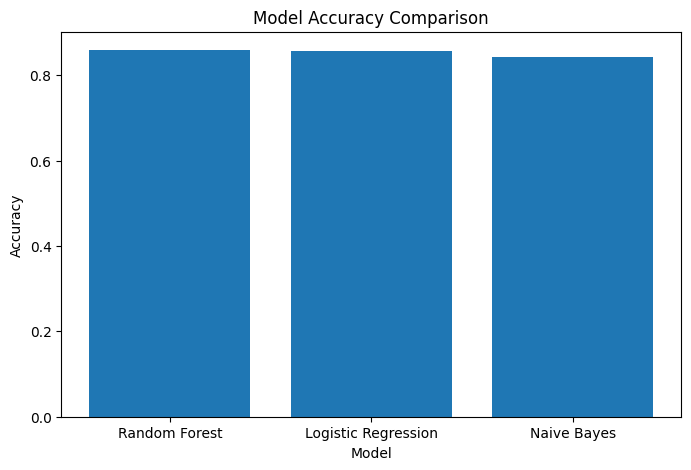

In [134]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison_df['Model'],
    comparison_df['Accuracy']
)

plt.title(
    'Model Accuracy Comparison'
)

plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.show()